In [25]:
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import pickle
from spectral.io import envi

from scipy.signal import medfilt, savgol_filter
from scipy.interpolate import splrep, splev, interp1d

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_analytical
from isofit.configs import configs
from isofit.core.geometry import Geometry

%matplotlib widget

In [34]:
home = '/store/carroll/col/data/2018/'

out_figs = '/store/carroll/col/figs/'

rccs_raw = np.loadtxt(os.path.join(home, 'test_roi', 'rcc_white_tarp_mean_20250829.txt'))

# isofit dirs
base_dir_reference = os.path.join(home, 'test_roi/calTarp/')
base_dir_test = os.path.join(home, 'test_rccs/')
reference_flights = [x for x in os.listdir(base_dir_reference) if x.startswith('NIS')]
reference_flights = ['_'.join(x.split('_')[:3]) for x in reference_flights]
test_flights = [x for x in os.listdir(base_dir_test) if x.startswith('NIS')]

# reference targets (calibration tarps)
with open(os.path.join(home, 'test_roi/single_pxs.pkl'), 'rb') as f:
    reference_px = pickle.load(f)
    
# bright, dark targets visually selected from multiple flightlines
with open(os.path.join(home, 'test_rccs/single_pxs.pkl'), 'rb') as f:
    bright_dark_px = pickle.load(f)

fp = glob(os.path.join(home, 'test_flightlines', '*', 'output', '*_rfl.hdr'))[0]
wl = np.array([float(x) for x in envi.read_envi_header(fp)['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

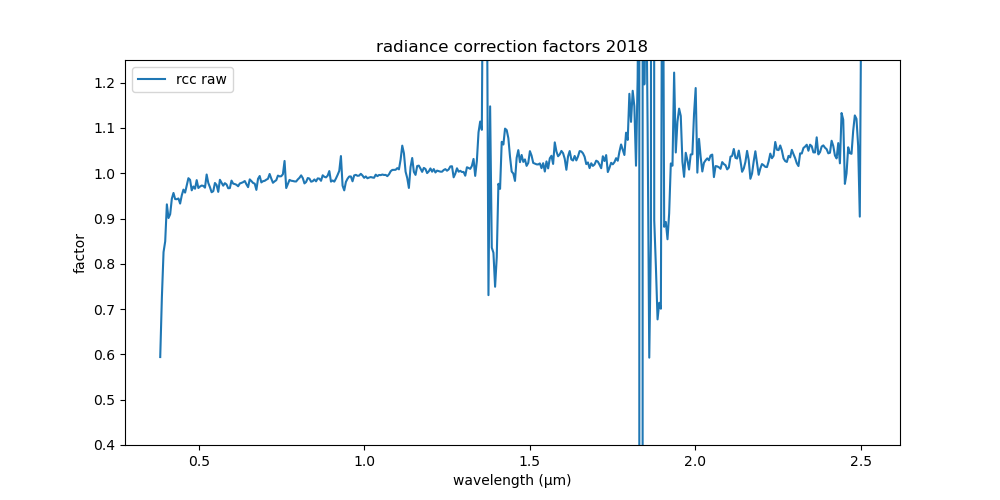

In [29]:
fig = plt.figure(figsize=(10,5))

plt.plot(wl, rccs_raw, label='rcc raw')

plt.xlabel('wavelength (μm)')
plt.ylabel('factor')
plt.ylim(0.4, 1.25)
plt.title('radiance correction factors 2018')
plt.legend()

# plt.savefig(os.path.join(out_figs, 'raw_rccs_2018.png'), dpi=300)

plt.show()

In [8]:
# retrieve rfl w adjusted radiance for each bright, dark test target

base_dir = base_dir_test

alg_rfl = []
modeled_rdns = []
observed_rdns = []

for flight_id in test_flights:
    for k in ['bright', 'dark']:
        working_dir = glob(os.path.join(base_dir, f'{flight_id}*'))[0]
        
        if base_dir==base_dir_reference:
            rdn = reference_px['rdn'][flight_id][k]
            obs = reference_px['obs'][flight_id][k]
            loc = reference_px['loc'][flight_id][k]
        else:
            rdn = bright_dark_px[flight_id][k]['rdn']
            obs = bright_dark_px[flight_id][k]['obs']
            loc = bright_dark_px[flight_id][k]['loc']
        
        # load config as-is
        fp_config = os.path.join(working_dir, 'config', f'{flight_id}_isofit.json')
        config = configs.create_new_config(fp_config)
        
        # set up forward model, io, inversion according to config
        fm = ForwardModel(config)
        io = IO(config, fm)
        inv = Inversion(config, fm)
        
        # load the isofit geometry representation of the single pixel
        geom = Geometry(obs=obs, loc=loc)
        geom.sky_view_factor = 1 # updated isofit dev 8/20 and now this is necessary? Not sure why skyview factor is no longer automatically populating to 1 when none provided
        
        # adjust rdn
        meas = rdn.copy()
        meas = meas*rccs_raw
        
        # retrieve rfl
        states=inv.invert(meas, geom)
        xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
        x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
        x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
        alg_rfl.append(x_alg)

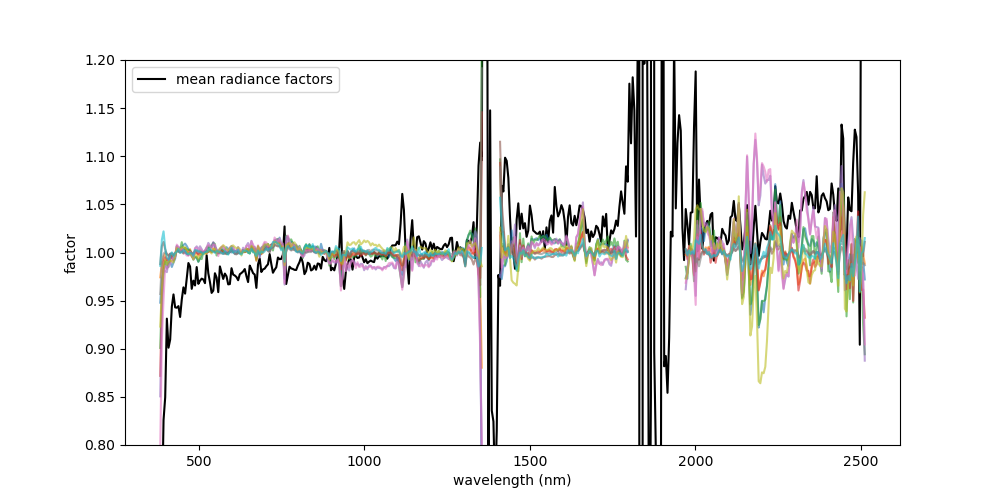

In [36]:
## from Phil - 

# visualize the delta between x_alg (from the rcc-adjusted rdn) and a smoothed linear interpolation of x_alg
# compare those deltas w/ rccs, across all bright/dark targets
# regions where the noise (deltas) are similar across targets and follow the trends of the rccs = regions we want to interpolate across

deltas = []

fig = plt.figure(figsize=(10,5))

exp_arr = np.array([5,10,13,20,27,35,42,50,60,75,85,100,150,180,210,220,250,260,280,320,340,350,380,400,420])
bin_size = 2
exp_lis = [np.mean(wl_nan[x-bin_size:x+bin_size]) for x in exp_arr]

plt.plot(wl, rccs_raw, color='black', label='mean radiance factors')

for i in range(len(alg_rfl)):
    rfl_lis = [np.mean(alg_rfl[i][x-bin_size:x+bin_size]) for x in exp_arr]
    interp = np.interp(wl_nan, exp_lis, rfl_lis)
    delta = alg_rfl[i] - interp
    deltas.append(delta)
    plt.plot(wl_nan, delta*5+1, alpha=0.6)
plt.ylabel('factor')
plt.xlabel('wavelength (nm)')
plt.ylim(0.8, 1.2)
plt.legend()
plt.show()

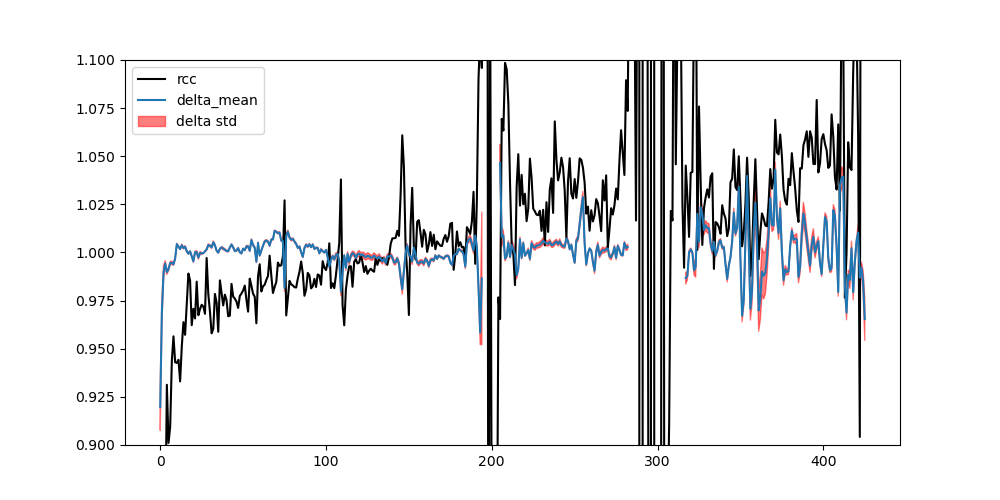

In [21]:
# mean and std from above

delta_mean = np.mean(deltas, axis=0)
delta_std = np.std(deltas, axis=0)
fig = plt.figure(figsize=(10,5))

plt.plot(rccs_raw, color='black', label='rcc')
plt.plot(delta_mean*5+1, label='delta_mean')
plt.fill_between(range(delta_mean.shape[0]), delta_mean*5+1 - delta_std, delta_mean*5+1 + delta_std, color='red', label='delta std', alpha=0.5)

plt.ylim(0.9, 1.1)

plt.legend()
plt.show()

In [38]:
wl = wl/1000

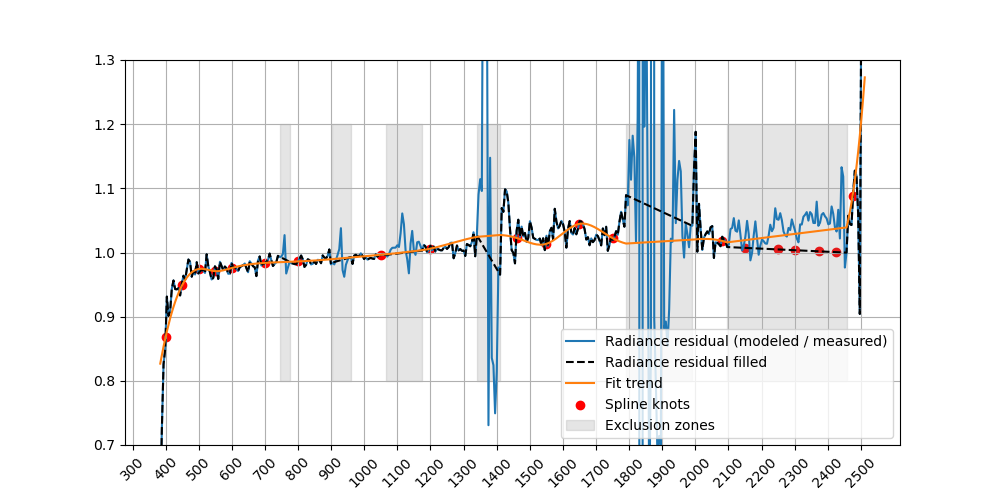

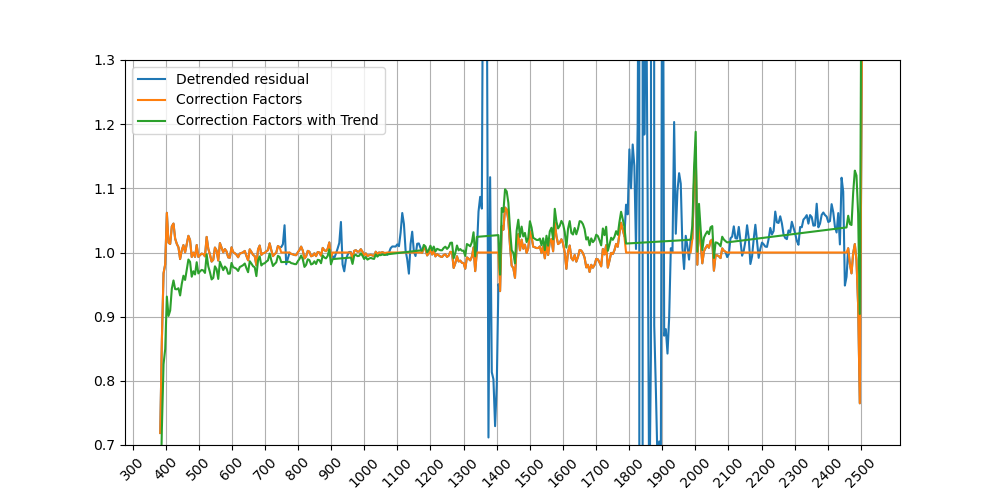

In [39]:
## from Phil - 

# Now it's time for the science/art - let's do some work to try and only get
# the influence of calibration, not the atmosphere.

def wl2ind(wl0):
    return np.argmin(np.abs(wl - wl0))

def ind2wl(ind0):
    return wl[ind0]

radiance_ratio = np.loadtxt(os.path.join(home, 'test_roi/rcc_white_tarp_mean_20250829.txt')) # mean factor across 4 calibration flightlines

radiance_ratio_adjusted = radiance_ratio.copy()
knots = np.array([400,450,500,550,600,700,800,1050,1200,1460,1550,1650,1750,2080,2150,2250,2300,2375,2425, 2475], dtype=np.float32)/1000.
ignore_zones = [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.34, 1.410], [1.79, 1.99], # water absorption regions (narrower)
                # [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.33, 1.465], [1.77, 2.05], # water absorption regions
                # [0.669, 0.679],
                [2.096, 2.458]] # identified systematics - most conservative
               # [0.669, 0.679], [2.096, 2.192], [2.231,2.269], [2.306, 2.317], [2.430, 2.460]] # identified systematics - less conservative

knot_average_window = 1

for a, b in ignore_zones:
    wl_subset = wl[np.logical_and(wl > a, wl < b)]
    radiance_ratio_adjusted[np.logical_and(wl > a, wl < b)] = interp1d([a,b],[radiance_ratio_adjusted[wl2ind(a)],radiance_ratio_adjusted[wl2ind(b)]])(wl_subset)

inds = np.array([wl2ind(q) for q in knots])
spline_y = np.array([np.mean(radiance_ratio_adjusted[x-knot_average_window:x+knot_average_window+1]) for x in inds])
spline = splrep(knots,spline_y)
y_trend  = splev(wl, spline)


y_detrend = radiance_ratio/y_trend
y_correction = radiance_ratio/y_trend
for ez in ignore_zones:
    y_correction[np.logical_and(wl > ez[0], wl < ez[1])] = 1
    y_trend[np.logical_and(wl > ez[0], wl < ez[1])] = interp1d([ez[0],ez[1]],[y_trend[wl2ind(ez[0])],y_trend[wl2ind(ez[1])]])(wl[np.logical_and(wl > ez[0], wl < ez[1])])


plt.figure(figsize=(10, 5))
plt.plot(io.meas_wl, radiance_ratio, label='Radiance residual (modeled / measured)')
plt.plot(io.meas_wl, radiance_ratio_adjusted, label='Radiance residual filled', c='black',ls='--')
plt.plot(io.meas_wl, y_trend, label='Fit trend')
plt.scatter(knots*1000, spline_y, color='r', label='Spline knots')
for _el, el in enumerate(ignore_zones):
    if _el == 0:
        plt.fill_between(np.array(el)*1000, 0.8, 1.2, color='grey', alpha=0.2, label='Exclusion zones')
    else:
        plt.fill_between(np.array(el)*1000, 0.8, 1.2, color='grey', alpha=0.2)

plt.ylim([0.7, 1.3])
plt.xticks(np.arange(300,2600,100),rotation=45)
plt.grid()
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(io.meas_wl, y_detrend, label='Detrended residual')
plt.plot(io.meas_wl, y_correction, label='Correction Factors')
plt.plot(io.meas_wl, y_correction*y_trend, label='Correction Factors with Trend')
plt.ylim([0.7, 1.3])
plt.xticks(np.arange(300,2600,100),rotation=45)
plt.grid()
plt.legend()

In [40]:
# use detrended or not? try both
fp_out = home + 'test_roi/rcc_white_tarp_mean_postprocess_detrended_20250829_wholeswir2.txt'
np.savetxt(fp_out, y_correction)

fp_out = home + 'test_roi/rcc_white_tarp_mean_postprocess_withtrend_20250829_wholeswir2.txt'
withtrend = y_correction*y_trend
np.savetxt(fp_out, withtrend)